In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

fonts = sorted({f.name for f in fm.fontManager.ttflist})
found = next((c for c in ['Malgun Gothic', 'NanumGothic', 'AppleGothic'] if c in fonts), None)
plt.rcParams['font.family'] = found
plt.rcParams['axes.unicode_minus'] = False

> ## 데이터 로드 및 전처리

**타깃**: `repurchase` (1=잔존, 0=이탈)

- `USER_KEY`, `USER_NUM`, `is_churn_prevented` 제외
- `watch_gap_max`, `watch_gap_mean` NaN -> 0
- `activity_rate`, `price_per_day` inf -> 0 (duration_days=0 유저 143명)
- `gender`, `product_cd`, `payment_device`, `billing_method` -> Label Encoding

In [2]:
df = pd.read_excel('final_merged_user(단칼)_v3.xlsx')

df['watch_gap_max']  = df['watch_gap_max'].fillna(0)
df['watch_gap_mean'] = df['watch_gap_mean'].fillna(0)
df.replace([np.inf, -np.inf], 0, inplace=True)

le = LabelEncoder()
for col in ['gender', 'product_cd', 'payment_device', 'billing_method']:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['USER_KEY', 'USER_NUM', 'repurchase', 'is_churn_prevented'])
y = df['repurchase']

print('X shape:', X.shape)
print('y:', y.value_counts().to_dict())
print('features:', X.columns.tolist())

X shape: (14433, 23)
y: {1: 9692, 0: 4741}
features: ['product_cd', 'billing_method', 'concurrent_streams', 'promotion_yn', 'payment_device', 'is_user_verified', 'gender', 'age', 'reg_hour', 'duration_days', 'total_sessions', 'max_daily_sessions', 'weekend_watch_ratio', 'first_watch_day', 'days_before_end_min', 'rewatch_ratio', 'avg_duration', 'watch_gap_max', 'watch_gap_mean', 'watch_gap_std', 'binge_day_count', 'activity_rate', 'price_per_day']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape[0], '/ Test:', X_test.shape[0])
print('Train churn rate:', round((y_train==0).mean(), 3))

Train: 11546 / Test: 2887
Train churn rate: 0.329


> ## 모델 학습 및 평가

3개 모델 비교: Logistic Regression / Random Forest / XGBoost

[Logistic Regression]
              precision    recall  f1-score   support

    churn(0)       0.63      0.12      0.20       948
   retain(1)       0.69      0.97      0.81      1939

    accuracy                           0.69      2887
   macro avg       0.66      0.54      0.50      2887
weighted avg       0.67      0.69      0.61      2887

ROC-AUC: 0.6255


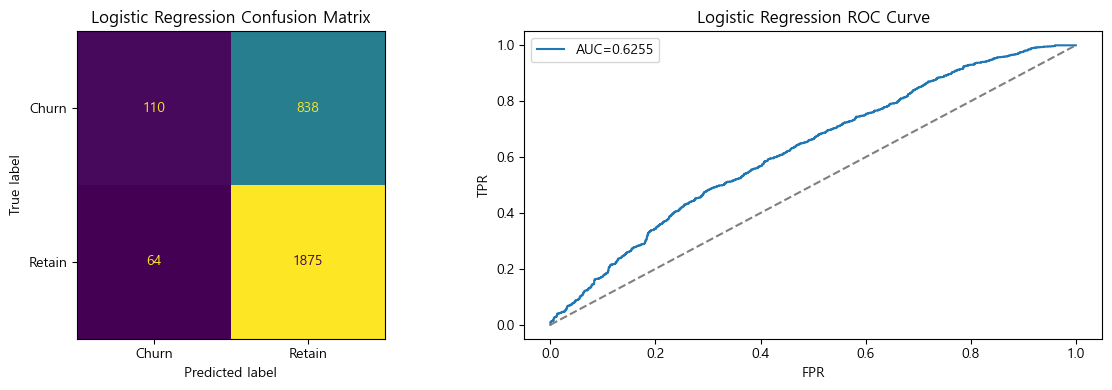

In [4]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    auc    = roc_auc_score(y_te, y_prob)
    print('='*50)
    print('[' + name + ']')
    print(classification_report(y_te, y_pred, target_names=['churn(0)', 'retain(1)']))
    print('ROC-AUC:', round(auc, 4))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
                           display_labels=['Churn', 'Retain']).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(name + ' Confusion Matrix')
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[1].plot(fpr, tpr, label='AUC=' + str(round(auc, 4)))
    axes[1].plot([0,1],[0,1],'--', color='gray')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title(name + ' ROC Curve')
    axes[1].legend()
    plt.tight_layout(); plt.show()
    return auc

results = {}
results['Logistic Regression'] = evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train, y_train, X_test, y_test
)

[Random Forest]
              precision    recall  f1-score   support

    churn(0)       0.53      0.20      0.29       948
   retain(1)       0.70      0.91      0.79      1939

    accuracy                           0.68      2887
   macro avg       0.62      0.56      0.54      2887
weighted avg       0.64      0.68      0.63      2887

ROC-AUC: 0.6251


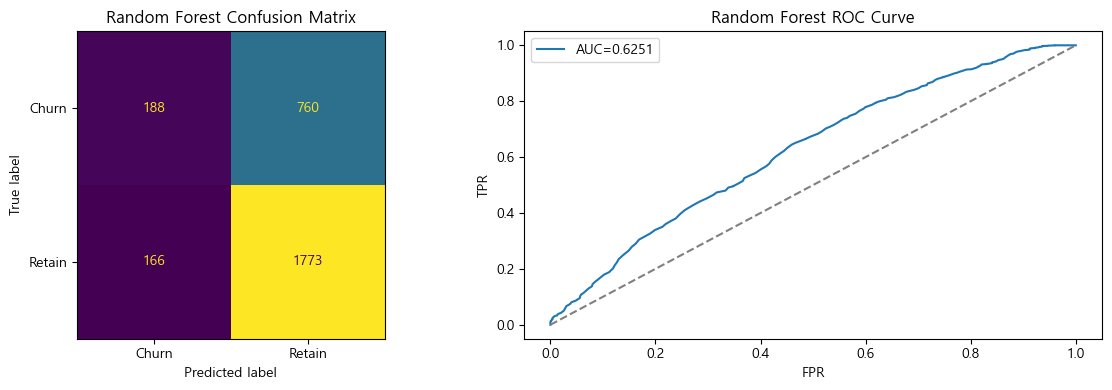

In [5]:
results['Random Forest'] = evaluate(
    'Random Forest',
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)

[XGBoost]
              precision    recall  f1-score   support

    churn(0)       0.54      0.20      0.30       948
   retain(1)       0.70      0.92      0.79      1939

    accuracy                           0.68      2887
   macro avg       0.62      0.56      0.55      2887
weighted avg       0.65      0.68      0.63      2887

ROC-AUC: 0.6258


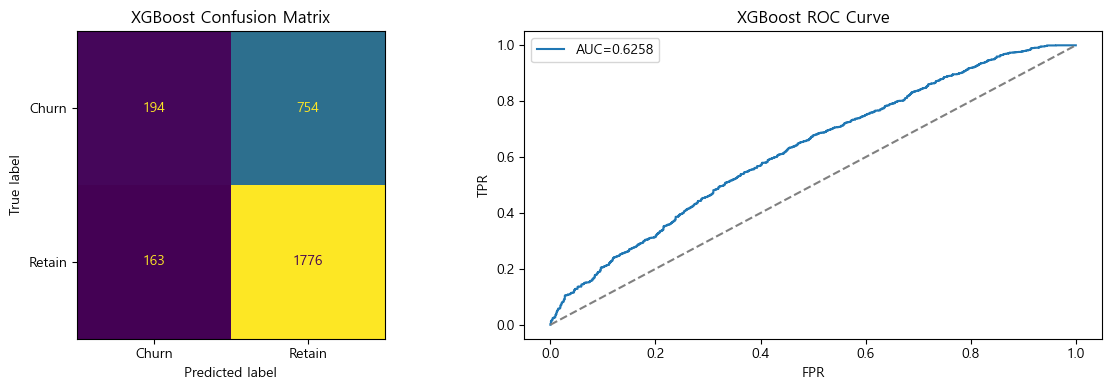

In [6]:
results['XGBoost'] = evaluate(
    'XGBoost',
    XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                  random_state=42, eval_metric='logloss', verbosity=0),
    X_train, y_train, X_test, y_test
)

[ ROC-AUC ]
  XGBoost                   AUC: 0.6258
  Logistic Regression       AUC: 0.6255
  Random Forest             AUC: 0.6251


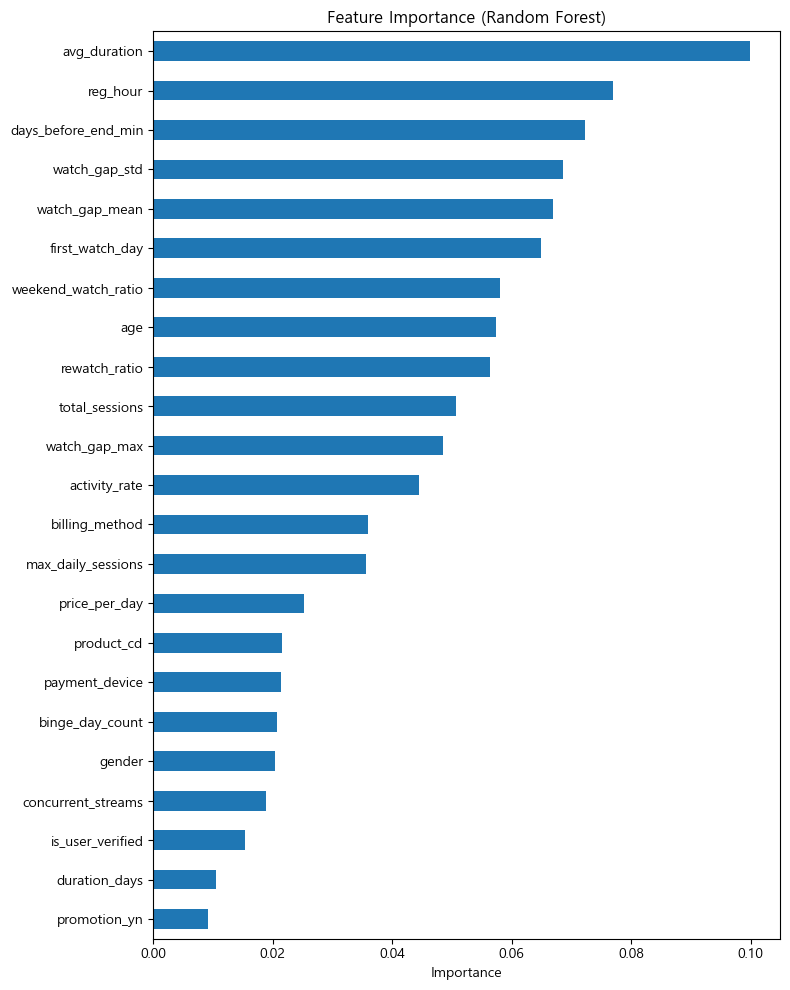

In [7]:
print('[ ROC-AUC ]')
for name, auc in sorted(results.items(), key=lambda x: -x[1]):
    print(' ', name.ljust(25), 'AUC:', round(auc, 4))

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 10))
imp.plot(kind='barh', ax=ax)
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

> ## 모델 성능 비교 요약

| 모델 | 이탈(0) F1 | 잔존(1) F1 | Macro F1 | Weighted F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.20 | 0.81 | 0.50 | 0.61 | 0.6255 |
| Random Forest       | 0.29 | 0.79 | 0.54 | 0.63 | 0.6251 |
| XGBoost             | 0.30 | 0.79 | 0.55 | 0.63 | 0.6258 |

**핵심 문제: 이탈(0) F1이 0.20~0.30으로 낮음**

Weighted F1 0.63은 잔존(1) 67%가 평균을 끌어올리는 착시.

**원인 추정**
1. 관측 기간 35일 - 정보량 부족
2. repurchase 신뢰도 - 구독 유효 유저 혼재 가능성
3. 클래스 불균형 - 모델이 잔존 쪽으로 쏠림